# Stock Price Prediction Using Machine Learning

## Objective
This project predicts stock closing prices using historical stock market data and a Linear Regression model.

## Technologies Used
- Python
- Pandas
- yFinance
- Scikit-learn
- Matplotlib

## Features
- Real stock market data collection
- Data preprocessing
- Machine learning regression model
- Price prediction
- Visualization of actual vs predicted prices

In [25]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [26]:
stock_data = yf.download('AAPL', start='2020-01-01', end='2025-01-01')

print(stock_data.head())
print(stock_data.shape)

[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.333885  72.394093  71.091191  71.344062  135480400
2020-01-03  71.630646  72.389265  71.406674  71.563213  146322800
2020-01-06  72.201401  72.239935  70.503539  70.754006  118387200
2020-01-07  71.861839  72.466322  71.642681  72.211041  108872000
2020-01-08  73.017830  73.318870  71.565614  71.565614  132079200
(1258, 5)


In [27]:
features = stock_data[['Open', 'High', 'Low', 'Volume']]

target = stock_data['Close']   # MUST be 1D Series

print(features.head())
print(target.head())

Price            Open       High        Low     Volume
Ticker           AAPL       AAPL       AAPL       AAPL
Date                                                  
2020-01-02  71.344062  72.394093  71.091191  135480400
2020-01-03  71.563213  72.389265  71.406674  146322800
2020-01-06  70.754006  72.239935  70.503539  118387200
2020-01-07  72.211041  72.466322  71.642681  108872000
2020-01-08  71.565614  73.318870  71.565614  132079200
Ticker           AAPL
Date                 
2020-01-02  72.333885
2020-01-03  71.630646
2020-01-06  72.201401
2020-01-07  71.861839
2020-01-08  73.017830


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)

(1006, 4) (252, 4)


In [29]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [32]:
predictions = model.predict(X_test).reshape(-1)

In [33]:
comparison = pd.DataFrame({
    'Actual Price': y_test.to_numpy().reshape(-1),
    'Predicted Price': predictions
})

print(comparison.head())

   Actual Price  Predicted Price
0    170.394104       169.216184
1     77.034630        77.803823
2     61.041298        59.741046
3     59.126953        58.320920
4    167.985016       167.880309


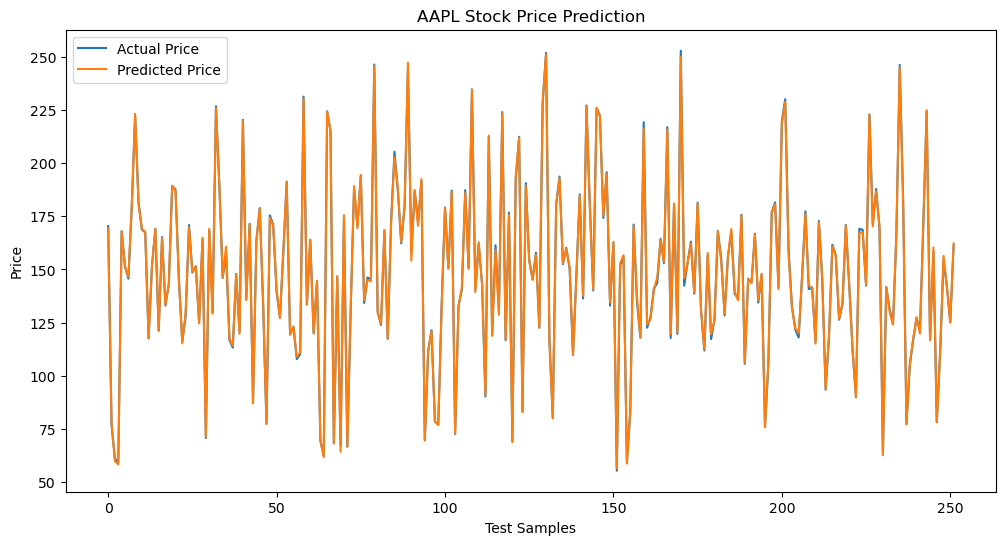

In [34]:
plt.figure(figsize=(12,6))

plt.plot(comparison['Actual Price'].values, label='Actual Price')
plt.plot(comparison['Predicted Price'].values, label='Predicted Price')

plt.title("AAPL Stock Price Prediction")
plt.xlabel("Test Samples")
plt.ylabel("Price")
plt.legend()
plt.show()

In [35]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.7418783343577513
RMSE: 0.9982197240439376


# Final Insights

- The Linear Regression model successfully learned stock price trends.
- Predicted prices closely follow actual market prices.
- Historical features such as Open, High, Low, and Volume are useful predictors.
- Machine learning can help analyze financial market patterns.